In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df_customer = pd.read_csv('/content/drive/MyDrive/BigDataAndDataMiningCoursework/Coursework_dataset/customers.csv')

In [ ]:
df_customer.head()

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group
0,cust_000001,Prakash Pradhan,prakash.pradhan282@yahoo.com,Kathmandu,Bagmati Province,Nepal,Retail,1/10/2021,18-25
1,cust_000002,Salim Khan,salim.khan693@gmail.com,Rajshahi,Rajshahi Division,Bangladesh,Wholesale,8/3/2020,36-50
2,cust_000003,Anita Patel,anita.patel96@yahoo.com,Bangalore,Karnataka,India,Retail,2/5/2019,36-50
3,cust_000004,Puspa Baral,puspa.baral28@yahoo.com,Hetauda,Bagmati Province,Nepal,Retail,10/21/2023,36-50
4,cust_000005,Radha Manandhar,radha.manandhar604@hotmail.com,Birgunj,Madhesh Province,Nepal,Retail,2/11/2018,18-25


In [ ]:
df_customer.shape

(120000, 9)

In [ ]:
df_customer.count()

,0
customer_id,120000
customer_name,120000
email,119200
city,120000
state_province,120000
country,120000
customer_segment,120000
registration_date,120000
age_group,119700


In [ ]:
df_customer.isnull().sum()

,0
customer_id,0
customer_name,0
email,800
city,0
state_province,0
country,0
customer_segment,0
registration_date,0
age_group,300


In [ ]:
df_customer[df_customer['email'].isnull()].head()

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group
17,cust_000018,Hema Tuladhar,NaN,Dharan,Koshi Province,Nepal,Premium,3/26/2019,36-50
29,cust_000030,Uttam Oli,NaN,Lalitpur,Bagmati Province,Nepal,Premium,5/1/2021,36-50
59,cust_000060,Deepak Oli,NaN,Dharan,Koshi Province,Nepal,Retail,6/11/2023,36-50
133,cust_000134,Gita Pradhan,NaN,Pokhara,Gandaki Province,Nepal,Retail,4/22/2023,36-50
310,cust_000311,Yamuna Rai,NaN,Pokhara,Gandaki Province,Nepal,Retail,1/26/2021,18-25


In [ ]:
print(df_customer["email"].duplicated().sum())
print(df_customer["customer_id"].duplicated().sum())
print(df_customer["customer_name"].duplicated().sum())
print(df_customer["city"].duplicated().sum())
print(df_customer["state_province"].duplicated().sum())
print(df_customer["country"].duplicated().sum())
print(df_customer["customer_segment"].duplicated().sum())
print(df_customer["state_province"].duplicated().sum())
print(df_customer["age_group"].duplicated().sum())

952
0
99710
119971
119977
119996
119996
119977
119995


In [ ]:
# Returns the total count of rows where BOTH customer_id and email are identical
duplicate_pairs_count = df_customer.duplicated(subset=["customer_id", "email"]).sum()

print(f"Total duplicated customer-email pairs: {duplicate_pairs_count}")

# To actually see the rows that are duplicated:
duplicate_rows = df_customer[df_customer.duplicated(subset=["customer_id", "email"], keep=False)]
print(duplicate_rows)

Total duplicated customer-email pairs: 0
Empty DataFrame
Columns: [customer_id, customer_name, email, city, state_province, country, customer_segment, registration_date, age_group]
Index: []


In [ ]:
# Returns an array of every unique country name
countries = df_customer['country'].unique()
print(countries)

['Nepal' 'Bangladesh' 'India' 'Sri Lanka']


In [ ]:
pattern = r'^[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+$'

# By adding na=True, we treat NaNs as "matching" temporarily
# so that the ~ flip turns them into False.
invalid_strings = df_customer[
    df_customer['email'].notnull() &
    ~df_customer['email'].str.match(pattern, na=True)
]

invalid_strings

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group
833,cust_000834,Lalitha De Silva,lalitha.de silva5@outlook.com,Kandy,Central Province,Sri Lanka,Retail,11/29/2020,26-35
2527,cust_002528,Hasaranga De Silva,hasaranga.de silva532@yahoo.com,Colombo,Western Province,Sri Lanka,Wholesale,6/13/2018,51+
3623,cust_003624,Sanath De Silva,sanath.de silva340@yahoo.com,Galle,Southern Province,Sri Lanka,Wholesale,4/19/2023,51+
3692,cust_003693,Dinesh De Silva,dinesh.de silva458@outlook.com,Kandy,Central Province,Sri Lanka,Retail,12/3/2023,51+
4656,cust_004657,Subashini De Silva,subashini.de silva885@yahoo.com,Colombo,Western Province,Sri Lanka,Wholesale,7/8/2023,51+
...,...,...,...,...,...,...,...,...,...
116430,cust_116431,Bandara De Silva,bandara.de silva290@outlook.com,Kandy,Central Province,Sri Lanka,Wholesale,6/14/2020,51+
116932,cust_116933,Kusal De Silva,kusal.de silva544@yahoo.com,Kandy,Central Province,Sri Lanka,Wholesale,6/24/2018,51+
118598,cust_118599,Buddhika De Silva,buddhika.de silva173@hotmail.com,Kandy,Central Province,Sri Lanka,Retail,3/11/2019,26-35
118931,cust_118932,Nilmini De Silva,nilmini.de silva577@hotmail.com,Colombo,Western Province,Sri Lanka,Retail,10/30/2020,18-25


In [ ]:
# This returns all rows where the customer_id is a repeat
duplicates = df_customer[df_customer.duplicated('customer_name', keep=False)]

# Sorting helps you see the pairs side-by-side
duplicates.sort_values(by='customer_name')

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group
61084,cust_061085,Abul Ahmed,abul.ahmed374@yahoo.com,Chittagong,Chittagong Division,Bangladesh,Wholesale,6/20/2021,51+
95769,cust_095770,Abul Ahmed,abul.ahmed772@gmail.com,Khulna,Khulna Division,Bangladesh,Retail,10/10/2021,26-35
223,cust_000224,Abul Ahmed,abul.ahmed301@hotmail.com,Dhaka,Dhaka Division,Bangladesh,Retail,5/2/2021,36-50
7173,cust_007174,Abul Akter,abul.akter107@yahoo.com,Dhaka,Dhaka Division,Bangladesh,Retail,8/16/2020,18-25
67355,cust_067356,Abul Akter,abul.akter856@hotmail.com,Sylhet,Sylhet Division,Bangladesh,Retail,12/15/2018,36-50
...,...,...,...,...,...,...,...,...,...
111542,cust_111543,Ziaur Sultana,ziaur.sultana449@hotmail.com,Khulna,Khulna Division,Bangladesh,Retail,11/29/2020,18-25
70887,cust_070888,Ziaur Sultana,ziaur.sultana431@outlook.com,Sylhet,Sylhet Division,Bangladesh,Premium,2/19/2020,18-25
78558,cust_078559,Ziaur Sultana,ziaur.sultana455@yahoo.com,Sylhet,Sylhet Division,Bangladesh,Premium,11/18/2021,26-35
114776,cust_114777,Ziaur Uddin,ziaur.uddin763@gmail.com,Chittagong,Chittagong Division,Bangladesh,Wholesale,9/4/2021,51+


In [ ]:
# This returns all rows where the customer_id is a repeat
duplicates = df_customer[df_customer.duplicated('email', keep=False).notnull()]

# Sorting helps you see the pairs side-by-side
duplicates.sort_values(by='email')

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group
223,cust_000224,Abul Ahmed,abul.ahmed301@hotmail.com,Dhaka,Dhaka Division,Bangladesh,Retail,5/2/2021,36-50
61084,cust_061085,Abul Ahmed,abul.ahmed374@yahoo.com,Chittagong,Chittagong Division,Bangladesh,Wholesale,6/20/2021,51+
95769,cust_095770,Abul Ahmed,abul.ahmed772@gmail.com,Khulna,Khulna Division,Bangladesh,Retail,10/10/2021,26-35
7173,cust_007174,Abul Akter,abul.akter107@yahoo.com,Dhaka,Dhaka Division,Bangladesh,Retail,8/16/2020,18-25
67355,cust_067356,Abul Akter,abul.akter856@hotmail.com,Sylhet,Sylhet Division,Bangladesh,Retail,12/15/2018,36-50
...,...,...,...,...,...,...,...,...,...
119301,cust_119302,Vijay Thakur,NaN,Hyderabad,Telangana,India,Retail,5/10/2023,18-25
119409,cust_119410,Krishna Bhandari,NaN,Kathmandu,Bagmati Province,Nepal,Premium,8/3/2023,36-50
119496,cust_119497,Dasun Herath,NaN,Galle,Southern Province,Sri Lanka,Wholesale,7/12/2021,36-50
119540,cust_119541,Prakash Baniya,NaN,Biratnagar,Koshi Province,Nepal,Retail,12/25/2021,18-25


In [ ]:
# Convert to datetime, turning invalid dates into NaT
df_customer['registration_date'] = pd.to_datetime(df_customer['registration_date'], errors='coerce')

# Now find the rows that became NaT (the invalid ones)
invalid_calendar_dates = df_customer[df_customer['registration_date'].isna()]

print("Rows with impossible dates (e.g., Feb 30):")
print(invalid_calendar_dates)

Rows with impossible dates (e.g., Feb 30):
Empty DataFrame
Columns: [customer_id, customer_name, email, city, state_province, country, customer_segment, registration_date, age_group]
Index: []


In [ ]:
import pandas as pd
from datetime import datetime

# Get today's date
today = datetime.now()

# Filter for dates in the future
future_dates = df_customer[df_customer['registration_date'] > today]

print("Rows with future registration dates:")
print(future_dates)

Rows with future registration dates:
Empty DataFrame
Columns: [customer_id, customer_name, email, city, state_province, country, customer_segment, registration_date, age_group]
Index: []


In [ ]:
# 1. Convert
df_customer['registration_date'] = pd.to_datetime(df_customer['registration_date'], errors='coerce')

# 2. Filter for NaT OR Future
today = datetime.now()
date_issues = df_customer[
    (df_customer['registration_date'].isna()) |
    (df_customer['registration_date'] > today)
]

date_issues.head()

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group


In [ ]:
import pandas as pd
from datetime import datetime

# 1. Convert to datetime (errors='coerce' handles things like Feb 30)
df_customer['registration_date'] = pd.to_datetime(df_customer['registration_date'], errors='coerce')

# 2. Define "Future" based on today (April 2026)
today = datetime.now()

# 3. Filter for dates that are either invalid (NaT) or in the future
date_anomalies = df_customer[
    (df_customer['registration_date'].isna()) |
    (df_customer['registration_date'] > today)
]

print("Date Issues Found:")
date_anomalies[['customer_name', 'registration_date']]

Date Issues Found:


,customer_name,registration_date


In [ ]:
# Check for duplicate emails (ignoring NaNs)
duplicate_emails = df_customer[
    df_customer['email'].notnull() &
    df_customer.duplicated(subset=['email'], keep=False)
]

print("Duplicate Email Accounts:")
duplicate_emails[['customer_name', 'email', 'city']]

Duplicate Email Accounts:


,customer_name,email,city
397,Dinesh Poudel,dinesh.poudel243@outlook.com,Dharan
541,Gita Oli,gita.oli833@outlook.com,Biratnagar
1767,Hema Dhakal,hema.dhakal218@hotmail.com,Nepalgunj
1907,Bishal Upreti,bishal.upreti172@yahoo.com,Nepalgunj
1931,Anil Khadka,anil.khadka607@yahoo.com,Birgunj
...,...,...,...
117370,Gita Adhikari,gita.adhikari526@hotmail.com,Kathmandu
118536,Bipin Sapkota,bipin.sapkota142@yahoo.com,Biratnagar
118543,Mukesh Magar,mukesh.magar499@outlook.com,Bharatpur
118590,Umesh Ghimire,umesh.ghimire753@outlook.com,Nepalgunj


In [ ]:
# This returns all rows where the customer_id is a repeat
duplicates = df_customer[df_customer.duplicated('customer_id', keep=False)]

# Sorting helps you see the pairs side-by-side
duplicates.sort_values(by='customer_id').head()

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group


In [ ]:
df_customer['state_province'].unique()

array(['Bagmati Province', 'Rajshahi Division', 'Karnataka',
       'Madhesh Province', 'Lumbini Province', 'Maharashtra',
       'Koshi Province', 'Chittagong Division', 'Dhaka Division', 'Bihar',
       'Tamil Nadu', 'Telangana', 'Western Province', 'Uttar Pradesh',
       'Gandaki Province', 'Northern Province', 'Delhi',
       'Sylhet Division', 'West Bengal', 'Central Province', 'Rajasthan',
       'Khulna Division', 'Southern Province'], dtype=object)

In [ ]:
df_customer['customer_segment'].unique()

array(['Retail', 'Wholesale', 'Premium', 'VIP'], dtype=object)

In [ ]:
df_customer[(df_customer['email'].str.strip() == '')]

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group


In [ ]:
df_customer['email'].isnull().sum()

np.int64(800)

In [ ]:
(df_customer['email'].str.strip() == '').sum()

np.int64(0)

In [ ]:
df_customer.loc[df_customer['email'].isnull(), 'email'] = "unknown@domain.com"

In [ ]:
df_customer[(df_customer['customer_id'] == 'cust_000018')]

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group
17,cust_000018,Hema Tuladhar,unknown@domain.com,Dharan,Koshi Province,Nepal,Premium,3/26/2019,36-50


In [ ]:
df_customer.count()

,0
customer_id,120000
customer_name,120000
email,120000
city,120000
state_province,120000
country,120000
customer_segment,120000
registration_date,120000
age_group,119700


In [ ]:
df_customer['age_group'].isnull().sum()

np.int64(300)

In [ ]:
df_customer[df_customer['age_group'].isnull()].head()

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group
407,cust_000408,Jyoti Rai,jyoti.rai257@yahoo.com,Kathmandu,Bagmati Province,Nepal,Premium,7/1/2022,NaN
457,cust_000458,Nurjahan Bhuiyan,nurjahan.bhuiyan848@hotmail.com,Rajshahi,Rajshahi Division,Bangladesh,Retail,7/25/2021,NaN
609,cust_000610,Sunil Limbu,sunil.limbu269@outlook.com,Pokhara,Gandaki Province,Nepal,Retail,10/11/2018,NaN
838,cust_000839,Priya Ghosh,priya.ghosh776@yahoo.com,Hyderabad,Telangana,India,Premium,5/31/2023,NaN
1512,cust_001513,Shahnaz Hawlader,shahnaz.hawlader5@gmail.com,Rajshahi,Rajshahi Division,Bangladesh,Wholesale,9/8/2018,NaN


In [ ]:
df_customer['age_group'].value_counts()

,count
age_group,
36-50,42545
26-35,35104
18-25,24812
51+,17239


In [ ]:
df_customer['age_group'] = df_customer['age_group'].fillna('unknown')

In [ ]:
df_customer['age_group'].isnull().sum()

np.int64(0)

In [ ]:
df_customer[(df_customer['customer_id'] == 'cust_000408')]

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group
407,cust_000408,Jyoti Rai,jyoti.rai257@yahoo.com,Kathmandu,Bagmati Province,Nepal,Premium,7/1/2022,unknown


In [ ]:
df_customer.count()

,0
customer_id,120000
customer_name,120000
email,120000
city,120000
state_province,120000
country,120000
customer_segment,120000
registration_date,120000
age_group,120000


In [ ]:
df_customer.duplicated().sum()

np.int64(0)

In [ ]:
df_customer.dtypes

,0
customer_id,object
customer_name,object
email,object
city,object
state_province,object
country,object
customer_segment,object
registration_date,object
age_group,object


In [ ]:
df_customer["registration_date"] = pd.to_datetime(df_customer["registration_date"], errors='coerce')

In [ ]:
df_customer.dtypes

,0
customer_id,object
customer_name,object
email,object
city,object
state_province,object
country,object
customer_segment,object
registration_date,datetime64[ns]
age_group,object


In [ ]:
df_customer

,customer_id,customer_name,email,city,state_province,country,customer_segment,registration_date,age_group
0,cust_000001,Prakash Pradhan,prakash.pradhan282@yahoo.com,Kathmandu,Bagmati Province,Nepal,Retail,2021-01-10,18-25
1,cust_000002,Salim Khan,salim.khan693@gmail.com,Rajshahi,Rajshahi Division,Bangladesh,Wholesale,2020-08-03,36-50
2,cust_000003,Anita Patel,anita.patel96@yahoo.com,Bangalore,Karnataka,India,Retail,2019-02-05,36-50
3,cust_000004,Puspa Baral,puspa.baral28@yahoo.com,Hetauda,Bagmati Province,Nepal,Retail,2023-10-21,36-50
4,cust_000005,Radha Manandhar,radha.manandhar604@hotmail.com,Birgunj,Madhesh Province,Nepal,Retail,2018-02-11,18-25
...,...,...,...,...,...,...,...,...,...
119995,cust_119996,Shanti Upreti,shanti.upreti984@gmail.com,Kathmandu,Bagmati Province,Nepal,Premium,2022-08-14,36-50
119996,cust_119997,Durga Chapagain,durga.chapagain239@hotmail.com,Dharan,Koshi Province,Nepal,Retail,2020-05-06,18-25
119997,cust_119998,Gopal Pokharel,gopal.pokharel127@gmail.com,Kathmandu,Bagmati Province,Nepal,Retail,2018-03-12,36-50
119998,cust_119999,Janaki Dangol,janaki.dangol62@outlook.com,Kathmandu,Bagmati Province,Nepal,Premium,2023-04-07,36-50


In [ ]:
df_customer.to_csv('customers.csv', index=False)

In [ ]:
import pandas as pd

In [ ]:
df_order = pd.read_csv("/content/drive/MyDrive/bigdata_sem6_grp4/Copy of orders.csv")

In [ ]:
df_order.head()

,order_id,customer_id,order_date,bs_year,order_status,payment_method,shipping_city,shipping_country,discount_pct
0,ord_000001,cust_049923,11/18/2023,2080,Cancelled,Connect IPS,Hetauda,Nepal,0.02
1,ord_000002,cust_008684,5/17/2023,2080,Shipped,Connect IPS,Kolkata,India,0.22
2,ord_000003,cust_067594,7/10/2022,2079,Returned,Cash on Delivery,Pokhara,Nepal,0.21
3,ord_000004,cust_055649,7/25/2023,2080,Delivered,Cash on Delivery,Butwal,Nepal,0.05
4,ord_000005,cust_038657,9/13/2020,2077,Delivered,Khalti,Birgunj,Nepal,0.02


In [ ]:
df_review = pd.read_csv("/content/drive/MyDrive/bigdata_sem6_grp4/Copy of reviews.csv")

In [ ]:
df_customer.columns, df_order.columns, df_review.columns

(Index(['customer_id', 'customer_name', 'email', 'city', 'state_province',
        'country', 'customer_segment', 'registration_date', 'age_group'],
       dtype='object'),
 Index(['order_id', 'customer_id', 'order_date', 'bs_year', 'order_status',
        'payment_method', 'shipping_city', 'shipping_country', 'discount_pct'],
       dtype='object'),
 Index(['review_id', 'order_id', 'product_id', 'review_score', 'review_date',
        'review_text', 'review_length_chars'],
       dtype='object'))

In [ ]:
# Assuming your dataframes are named df_review and df_order
orphan_reviews = df_review[~df_review['order_id'].isin(df_order['order_id'])]

if orphan_reviews.empty:
    print("Success: No orphan reviews found. All review order_ids exist in the orders table.")
else:
    print(f"Warning: Found {len(orphan_reviews)} orphan reviews!")
    print(orphan_reviews[['review_id', 'order_id']])

Success: No orphan reviews found. All review order_ids exist in the orders table.


In [ ]:
# Assuming your dataframes are named df_review and df_order
orphan_reviews = df_order[~df_order['customer_id'].isin(df_customer['customer_id'])]

if orphan_reviews.empty:
    print("Success: No orphan reviews found. All review order_ids exist in the orders table.")
else:
    print(f"Warning: Found {len(orphan_reviews)} orphan reviews!")
    print(orphan_reviews)

          order_id  customer_id  order_date  bs_year order_status  \
898     ord_000899  cust_120339  11/26/2023     2080    Cancelled   
1240    ord_001241  cust_120330  11/19/2023     2080      Shipped   
1333    ord_001334  cust_120204  12/10/2022     2079    Delivered   
1515    ord_001516  cust_121003  11/17/2021     2078    Delivered   
1852    ord_001853  cust_120863   11/6/2022     2079    Delivered   
...            ...          ...         ...      ...          ...   
398199  ord_398200  cust_120150    6/5/2022     2079      Shipped   
398285  ord_398286  cust_120779    5/4/2023     2080    Delivered   
398674  ord_398675  cust_121079    3/9/2023     2079    Cancelled   
400318  ord_023889  cust_120907  10/28/2020     2077      Shipped   
400452  ord_139288  cust_120344  11/23/2023     2080      Shipped   

          payment_method shipping_city shipping_country  discount_pct  
898          Connect IPS     Kathmandu            Nepal          0.23  
1240               eSewa   

In [ ]:
# First, ensure all date columns are actually datetime objects
df_customer['registration_date'] = pd.to_datetime(df_customer['registration_date'], errors='coerce')
df_order['order_date'] = pd.to_datetime(df_order['order_date'], errors='coerce')
df_review['review_date'] = pd.to_datetime(df_review['review_date'], errors='coerce')

# Merge Orders with Customers to check registration vs order date
df_order_cust = df_order.merge(df_customer[['customer_id', 'registration_date']], on='customer_id', how='left')

# Merge Reviews with Orders to check order vs review date
df_review_order = df_review.merge(df_order[['order_id', 'order_date']], on='order_id', how='left')

In [ ]:
# Logic: Order should be AFTER or ON the registration date
invalid_orders = df_order_cust[df_order_cust['order_date'] < df_order_cust['registration_date']]

print(f"Found {len(invalid_orders)} orders placed before registration.")
invalid_orders[['customer_id', 'registration_date', 'order_date', 'order_id']].head()

Found 0 orders placed before registration.


,customer_id,registration_date,order_date,order_id


In [ ]:
# Logic: Review should be AFTER or ON the order date
invalid_reviews = df_review_order[df_review_order['review_date'] < df_review_order['order_date']]

print(f"Found {len(invalid_reviews)} reviews written before the order was placed.")
invalid_reviews[['order_id', 'order_date', 'review_date', 'review_id']].head()

Found 180 reviews written before the order was placed.


,order_id,order_date,review_date,review_id
1593,ord_149926,2021-01-08,2020-07-13,rev_001594
4250,ord_147311,2023-12-13,2023-10-07,rev_004248
4314,ord_130062,2022-05-29,2022-04-25,rev_004312
5062,ord_329279,2023-02-04,2022-11-15,rev_005060
5229,ord_008064,2021-12-20,2021-07-07,rev_005227


In [ ]:
# 1. Merge reviews with orders to get BOTH customer_id and order_date
df_review_check = df_review.merge(
    df_order[['order_id', 'customer_id', 'order_date']],
    on='order_id',
    how='left'
)

# 2. Merge with customers to get the registration_date
df_review_check = df_review_check.merge(
    df_customer[['customer_id', 'registration_date']],
    on='customer_id',
    how='left'
)

# 3. Identify the "Time Travelers"
invalid_reviews_before_reg = df_review_check[
    df_review_check['review_date'] < df_review_check['registration_date']
]

print(f"Total reviews written before registration: {len(invalid_reviews_before_reg)}")

# 4. Display with the order_date included for a full timeline view
columns_to_show = ['review_id', 'customer_id', 'registration_date', 'order_date', 'review_date']
invalid_reviews_before_reg[columns_to_show].head()

Total reviews written before registration: 62


,review_id,customer_id,registration_date,order_date,review_date
4314,rev_004312,cust_006167,2022-05-16,2022-05-29,2022-04-25
5062,rev_005060,cust_032952,2023-01-22,2023-02-04,2022-11-15
6406,rev_006403,cust_116493,2019-05-03,2019-10-10,2019-04-14
11448,rev_011442,cust_090613,2019-12-02,2019-12-17,2019-11-15
29554,rev_029515,cust_044673,2022-07-23,2022-08-13,2022-02-27


In [ ]:
dff_customer = pd.read_csv("/content/drive/MyDrive/bigdata_sem6_grp4/Copy of customers.csv")
dff_date_dim = pd.read_csv("/content/drive/MyDrive/bigdata_sem6_grp4/Copy of date_dim_helper.csv")
dff_orders = pd.read_csv("/content/drive/MyDrive/bigdata_sem6_grp4/Copy of orders.csv")
dff_order_item = pd.read_csv("/content/drive/MyDrive/bigdata_sem6_grp4/Copy of order_items.csv")
dff_products = pd.read_csv("/content/drive/MyDrive/bigdata_sem6_grp4/Copy of products.csv")
dff_review = pd.read_csv("/content/drive/MyDrive/bigdata_sem6_grp4/Copy of reviews.csv")
dff_supplier = pd.read_csv("/content/drive/MyDrive/bigdata_sem6_grp4/Copy of suppliers.csv")

In [ ]:
dff_customer.columns, dff_date_dim.columns, dff_orders.columns, dff_order_item.columns, dff_products.columns, dff_review.columns, dff_supplier.columns

(Index(['customer_id', 'customer_name', 'email', 'city', 'state_province',
        'country', 'customer_segment', 'registration_date', 'age_group'],
       dtype='object'),
 Index(['date_id', 'full_date', 'day_of_week', 'day_number', 'month_number',
        'month_name', 'quarter', 'year', 'is_weekend', 'is_np_holiday'],
       dtype='object'),
 Index(['order_id', 'customer_id', 'order_date', 'bs_year', 'order_status',
        'payment_method', 'shipping_city', 'shipping_country', 'discount_pct'],
       dtype='object'),
 Index(['order_item_id', 'order_id', 'product_id', 'quantity',
        'unit_price_at_sale', 'line_total'],
       dtype='object'),
 Index(['product_id', 'product_name', 'category', 'subcategory', 'unit_price',
        'supplier_id', 'weight_kg', 'is_active'],
       dtype='object'),
 Index(['review_id', 'order_id', 'product_id', 'review_score', 'review_date',
        'review_text', 'review_length_chars'],
       dtype='object'),
 Index(['supplier_id', 'supplier_name',

In [ ]:
# Merge items with product catalog
df_price_audit = dff_order_item.merge(
    dff_products[['product_id', 'product_name', 'unit_price', 'category']],
    on='product_id',
    how='left'
)

# Rename for clarity
df_price_audit = df_price_audit.rename(columns={'unit_price': 'catalog_price'})

# Filter for the 5,412 records where sale price > catalog price
price_outliers = df_price_audit[
    df_price_audit['unit_price_at_sale'] > df_price_audit['catalog_price']
].copy()

# Calculate the Magnitude of the error
price_outliers['extra_charge'] = price_outliers['unit_price_at_sale'] - price_outliers['catalog_price']
price_outliers['pct_increase'] = (priace_outliers['extra_charge'] / price_outliers['catalog_price']) * 100

print(f"Detected {len(price_outliers)} pricing anomalies.")

Detected 5412 pricing anomalies.


In [ ]:
# Select and reorder columns for a clear report
report_cols = [
    'order_id',
    'product_name',
    'category',
    'catalog_price',      # Original price from products table
    'unit_price_at_sale', # Price actually charged
    'extra_charge',       # The difference
    'pct_increase'        # Percentage markup
]

# Display the top 20 anomalies, sorted by the highest percentage increase
# This helps identify if it's a small rounding error or a major glitch
print("--- Top Pricing Anomalies (Highest % Increase) ---")
display(price_outliers[report_cols].sort_values(by='pct_increase', ascending=False).head(20))

# Also display basic stats to see the average "extra" amount charged
print("\n--- Summary Statistics of Extra Charges ---")
display(price_outliers[['extra_charge', 'pct_increase']].describe())

--- Top Pricing Anomalies (Highest % Increase) ---


,order_id,product_name,category,catalog_price,unit_price_at_sale,extra_charge,pct_increase
918815,ord_396001,Pre-Workout Energy Neo,Beauty & Health,0.0,405.0,405.0,inf
391,ord_000180,Cushion Cover Set Mini,Home & Garden,0.0,440.0,440.0,inf
692,ord_000318,Orange Juice Pack,Food & Grocery,0.0,440.0,440.0,inf
1215,ord_000563,Leadership Lessons Neo,Books,0.0,410.0,410.0,inf
910219,ord_309655,Probiotics Daily Core,Beauty & Health,0.0,385.0,385.0,inf
910082,ord_308377,BCAA Recovery Powder SE,Beauty & Health,0.0,465.0,465.0,inf
909969,ord_307146,Probiotics Daily Core,Beauty & Health,0.0,395.0,395.0,inf
908731,ord_295220,Probiotics Daily Core,Beauty & Health,0.0,440.0,440.0,inf
908527,ord_293088,Probiotics Daily Core,Beauty & Health,0.0,490.0,490.0,inf
907881,ord_286979,Probiotics Daily Core,Beauty & Health,0.0,390.0,390.0,inf



--- Summary Statistics of Extra Charges ---


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,extra_charge,pct_increase
count,5412.000000,5412.0
mean,438.560606,inf
std,36.112330,NaN
min,375.000000,inf
25%,410.000000,NaN
50%,440.000000,NaN
75%,470.000000,NaN
max,500.000000,inf


In [ ]:
# Fix: Ensure product_id is in the merge
df_price_audit = dff_order_item.merge(
    dff_products[['product_id', 'product_name', 'unit_price', 'category']],
    on='product_id',
    how='left'
)

df_price_audit = df_price_audit.rename(columns={'unit_price': 'catalog_price'})

price_outliers = df_price_audit[
    df_price_audit['unit_price_at_sale'] > df_price_audit['catalog_price']
].copy()

# Fixed the typo: 'priace_outliers' -> 'price_outliers'
price_outliers['extra_charge'] = price_outliers['unit_price_at_sale'] - price_outliers['catalog_price']
price_outliers['pct_increase'] = (price_outliers['extra_charge'] / price_outliers['catalog_price']) * 100

print(f"Detected {len(price_outliers)} pricing anomalies.")

# Added 'product_id' to the report columns
report_cols = [
    'order_id',
    'product_id',          # Included as requested
    'product_name',
    'category',
    'catalog_price',
    'unit_price_at_sale',
    'extra_charge',
    'pct_increase'
]

print("--- Top Pricing Anomalies (Highest % Increase) ---")
display(price_outliers[report_cols].sort_values(by='pct_increase', ascending=False).head(5412))


Detected 5412 pricing anomalies.
--- Top Pricing Anomalies (Highest % Increase) ---


,order_id,product_id,product_name,category,catalog_price,unit_price_at_sale,extra_charge,pct_increase
918815,ord_396001,prod_03553,Pre-Workout Energy Neo,Beauty & Health,0.0,405.0,405.0,inf
391,ord_000180,prod_01897,Cushion Cover Set Mini,Home & Garden,0.0,440.0,440.0,inf
692,ord_000318,prod_04693,Orange Juice Pack,Food & Grocery,0.0,440.0,440.0,inf
1215,ord_000563,prod_02257,Leadership Lessons Neo,Books,0.0,410.0,410.0,inf
910219,ord_309655,prod_03475,Probiotics Daily Core,Beauty & Health,0.0,385.0,385.0,inf
...,...,...,...,...,...,...,...,...
2096,ord_000963,prod_01897,Cushion Cover Set Mini,Home & Garden,0.0,500.0,500.0,inf
1529,ord_000703,prod_01453,Coffee Table Glass Mini,Home & Garden,0.0,415.0,415.0,inf
1499,ord_000689,prod_01760,Compost Bin Kitchen XL,Home & Garden,0.0,455.0,455.0,inf
1383,ord_000637,prod_00187,DualSIM Pro Air,Electronics,0.0,475.0,475.0,inf


In [ ]:
# 1. Merge items with product catalog
df_price_audit = dff_order_item.merge(
    dff_products[['product_id', 'product_name', 'unit_price', 'category']],
    on='product_id',
    how='left'
)

df_price_audit = df_price_audit.rename(columns={'unit_price': 'catalog_price'})

# 2. Filter: Sale price > Catalog price AND Catalog price must be greater than 0
# This skips the "Free" items that would break your percentage calculation
price_outliers = df_price_audit[
    (df_price_audit['unit_price_at_sale'] > df_price_audit['catalog_price']) &
    (df_price_audit['catalog_price'] > 0)
].copy()

# 3. Calculate the Magnitude of the error safely
price_outliers['extra_charge'] = price_outliers['unit_price_at_sale'] - price_outliers['catalog_price']
price_outliers['pct_increase'] = (price_outliers['extra_charge'] / price_outliers['catalog_price']) * 100

print(f"Detected {len(price_outliers)} pricing anomalies (skipping zero-priced catalog items).")

# 4. Report Columns
report_cols = [
    'order_id',
    'product_id',
    'product_name',
    'category',
    'catalog_price',
    'unit_price_at_sale',
    'extra_charge',
    'pct_increase'
]

print("--- Top Pricing Anomalies (Highest % Increase) ---")
display(price_outliers[report_cols].sort_values(by='pct_increase', ascending=False).head(100))

Detected 0 pricing anomalies (skipping zero-priced catalog items).
--- Top Pricing Anomalies (Highest % Increase) ---


,order_id,product_id,product_name,category,catalog_price,unit_price_at_sale,extra_charge,pct_increase


In [ ]:
# Quick check for items sold that had a 0 catalog price
zero_catalog_sales = df_price_audit[
    (df_price_audit['catalog_price'] == 0) &
    (df_price_audit['unit_price_at_sale'] > 0)
]
print(f"Number of items sold that have a $0 catalog price: {len(zero_catalog_sales)}")

Number of items sold that have a $0 catalog price: 5412


In [ ]:
print("\n--- Summary Statistics of Extra Charges ---")
display(price_outliers[['extra_charge', 'pct_increase']].describe())


--- Summary Statistics of Extra Charges ---


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,extra_charge,pct_increase
count,5412.000000,5412.0
mean,438.560606,inf
std,36.112330,NaN
min,375.000000,inf
25%,410.000000,NaN
50%,440.000000,NaN
75%,470.000000,NaN
max,500.000000,inf


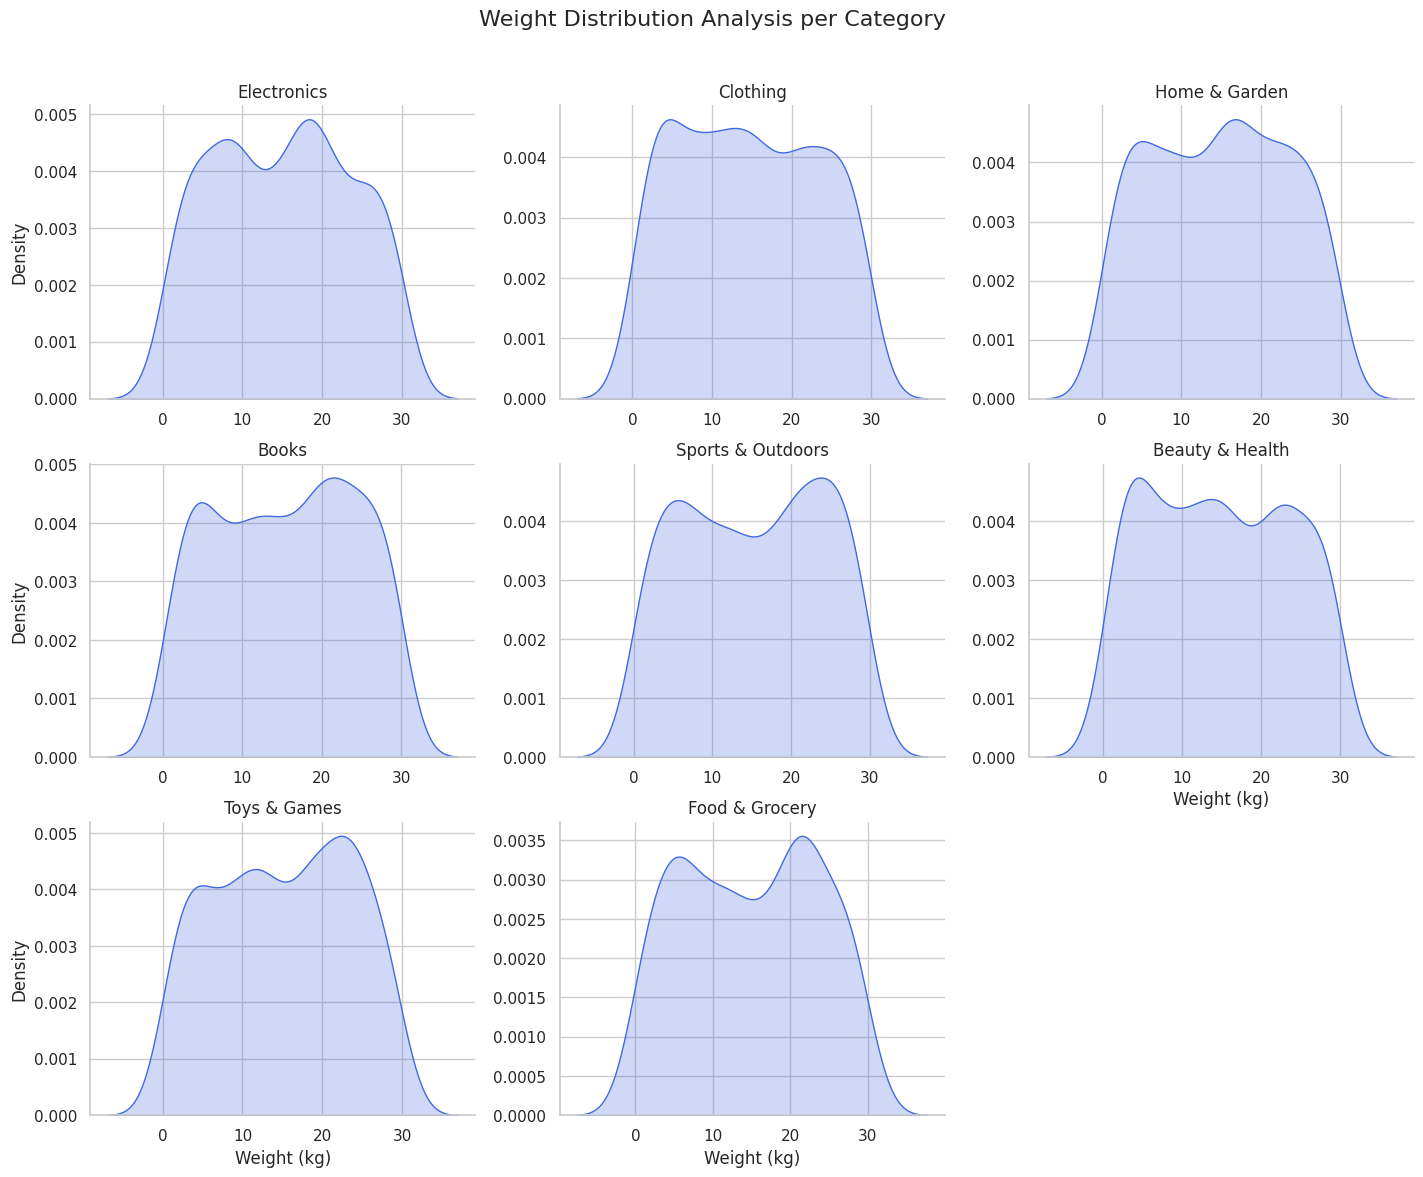

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data
plot_df = dff_products[['category', 'weight_kg']].dropna()
plot_df = plot_df[plot_df['weight_kg'] > 0]

# 2. Use displot with 'col' to create separate subplots
# col_wrap=3 means it will start a new row after every 3 charts
g = sns.displot(
    data=plot_df,
    x="weight_kg",
    col="category",
    kind="kde",
    col_wrap=3,
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False, 'sharex': False},
    fill=True,
    color='royalblue'
)

# 3. Clean up labels
g.set_axis_labels("Weight (kg)", "Density")
g.set_titles("{col_name}") # This puts the Category name as the title of each subplot

plt.subplots_adjust(top=0.9) # Make room for a main title
g.fig.suptitle('Weight Distribution Analysis per Category', fontsize=16)

plt.savefig('separated_bell_curves.png')
plt.show()

/tmp/ipykernel_9326/3207139355.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


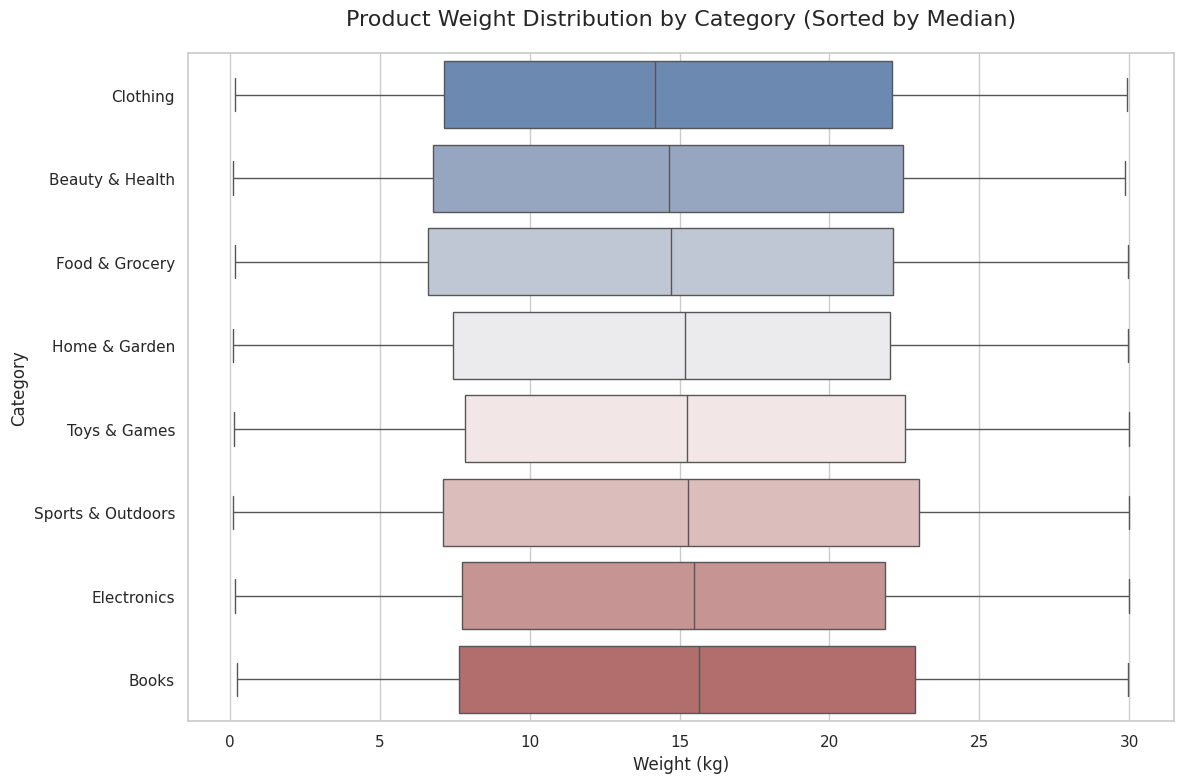

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare and clean the data
# Filter out missing weights and ensure we only look at positive values
box_df = dff_products[['category', 'weight_kg']].dropna()
box_df = box_df[box_df['weight_kg'] > 0]

# 2. Sort categories by median weight for a cleaner look
category_order = box_df.groupby('category')['weight_kg'].median().sort_values().index

# 3. Create the Box Plot
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=box_df,
    y='category',
    x='weight_kg',
    order=category_order,
    palette='vlag',
    fliersize=4  # Size of the outlier dots
)

# 4. Formatting
plt.title('Product Weight Distribution by Category (Sorted by Median)', fontsize=16, pad=20)
plt.xlabel('Weight (kg)', fontsize=12)
plt.ylabel('Category', fontsize=12)

# Optional: Uncomment the line below if weights vary by several orders of magnitude
# plt.xscale('log')

plt.tight_layout()
plt.savefig('product_weight_boxplot.png')
plt.show()

In [ ]:
dff_products['weight_kg'].unique()

array([ 6.95,  2.22, 14.61, ..., 27.63,  4.47,  4.45])

In [ ]:
max_price = dff_products['unit_price'].max()

most_expensive_laptop = dff_products.loc[dff_products['unit_price'].idxmax()]

print(f"The maximum price is: ${max_price:,.2f}")
print(f"The most expensive item is the {most_expensive_laptop['product_name']} ({most_expensive_laptop['product_id']})")

The maximum price is: $49,980.56
The most expensive item is the Noise Cancelling Headset Pro (prod_00535)
